In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PICKUPS_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hourly_pickups.parquet"
)

WEATHER_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hourly_weather.parquet"
)

pickups = pd.read_parquet(PICKUPS_FILE)
weather = pd.read_parquet(WEATHER_FILE)

print(f"Pickup rows: {len(pickups):,}")
print(f"Weather rows: {len(weather):,}")

display(weather.head())

Pickup rows: 72,000
Weather rows: 2,880


,timestamp,temperature_c,apparent_temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,weather_code
0,2026-01-01 00:00:00,-1.0,-5.9,62,0.0,13.0,3
1,2026-01-01 01:00:00,-0.8,-5.7,65,0.1,13.0,71
2,2026-01-01 02:00:00,-0.4,-5.3,65,0.1,13.3,71
3,2026-01-01 03:00:00,-0.2,-5.0,66,0.0,13.4,3
4,2026-01-01 04:00:00,0.4,-4.5,66,0.0,14.0,3


In [2]:
combined = pickups.merge(
    weather,
    on="timestamp",
    how="left",
    validate="many_to_one",
)

weather_columns = [
    "temperature_c",
    "apparent_temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "wind_speed_kmh",
    "weather_code",
]

print(f"Rows before merge: {len(pickups):,}")
print(f"Rows after merge: {len(combined):,}")
print(
    "Missing weather values:",
    combined[weather_columns].isna().sum().sum(),
)

combined.head()

Rows before merge: 72,000
Rows after merge: 72,000
Missing weather values: 0


,timestamp,station_id,station_name,pickups,temperature_c,apparent_temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,weather_code
0,2026-01-01,6140.05,W 21 St & 6 Ave,3,-1.0,-5.9,62,0.0,13.0,3
1,2026-01-01,6233.04,Pier 61 at Chelsea Piers,0,-1.0,-5.9,62,0.0,13.0,3
2,2026-01-01,5788.13,Lafayette St & E 8 St,4,-1.0,-5.9,62,0.0,13.0,3
3,2026-01-01,6331.01,W 31 St & 7 Ave,2,-1.0,-5.9,62,0.0,13.0,3
4,2026-01-01,6492.08,9 Ave & W 33 St,7,-1.0,-5.9,62,0.0,13.0,3


In [3]:
daily_pickups = (
    pickups.assign(
        date=pickups["timestamp"].dt.normalize(),
    )
    .groupby(
        "date",
        as_index=False,
    )
    .agg(
        total_pickups=("pickups", "sum"),
        mean_hourly_pickups=("pickups", "mean"),
    )
)

daily_weather = (
    weather.assign(
        date=weather["timestamp"].dt.normalize(),
    )
    .groupby(
        "date",
        as_index=False,
    )
    .agg(
        mean_temperature_c=("temperature_c", "mean"),
        mean_apparent_temperature_c=(
            "apparent_temperature_c",
            "mean",
        ),
        total_precipitation_mm=("precipitation_mm", "sum"),
        mean_humidity_pct=("relative_humidity_pct", "mean"),
        mean_wind_speed_kmh=("wind_speed_kmh", "mean"),
    )
)

daily = daily_pickups.merge(
    daily_weather,
    on="date",
    how="inner",
    validate="one_to_one",
)

final_week_daily = daily[
    daily["date"].between(
        "2026-04-24",
        "2026-04-30",
    )
].copy()

display(
    final_week_daily.round(2)
)

C:\Users\Sean\AppData\Local\Temp\ipykernel_53096\2932801807.py:50: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  final_week_daily.round(2)


,date,total_pickups,mean_hourly_pickups,mean_temperature_c,mean_apparent_temperature_c,total_precipitation_mm,mean_humidity_pct,mean_wind_speed_kmh
113,2026-04-24,10576,17.63,14.97,12.34,0.0,44.62,8.17
114,2026-04-25,2365,3.94,7.83,4.65,22.4,73.96,11.03
115,2026-04-26,6964,11.61,8.70,5.90,5.0,77.71,10.60
116,2026-04-27,9968,16.61,11.85,10.05,0.0,65.29,6.71
117,2026-04-28,10894,18.16,12.32,10.08,0.0,56.58,5.86
118,2026-04-29,9868,16.45,12.17,10.11,2.4,65.71,8.09
119,2026-04-30,9665,16.11,11.90,10.35,8.0,78.83,7.18


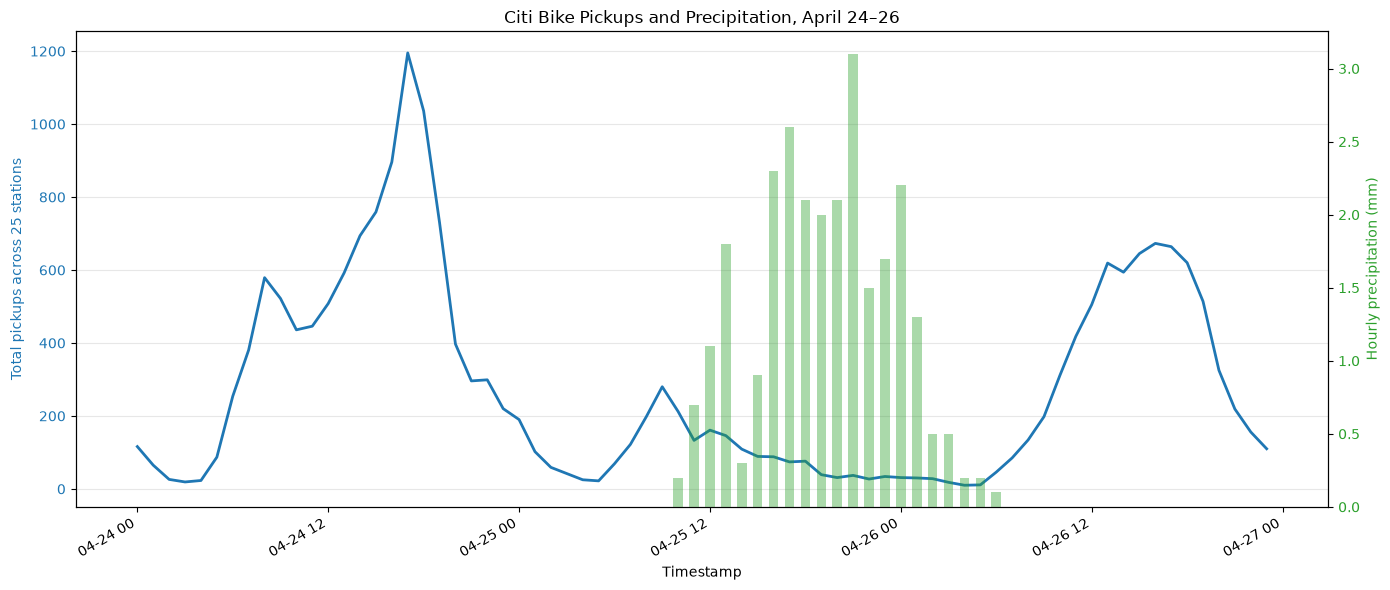

In [4]:
hourly_pickups = (
    pickups.groupby(
        "timestamp",
        as_index=False,
    )
    .agg(
        total_pickups=("pickups", "sum"),
    )
)

hourly_analysis = hourly_pickups.merge(
    weather,
    on="timestamp",
    how="inner",
    validate="one_to_one",
)

storm_period = hourly_analysis[
    hourly_analysis["timestamp"].between(
        "2026-04-24 00:00:00",
        "2026-04-26 23:00:00",
    )
].copy()

fig, pickup_axis = plt.subplots(
    figsize=(14, 6),
)

pickup_axis.plot(
    storm_period["timestamp"],
    storm_period["total_pickups"],
    color="tab:blue",
    linewidth=2,
    label="Total pickups",
)

pickup_axis.set_xlabel("Timestamp")
pickup_axis.set_ylabel(
    "Total pickups across 25 stations",
    color="tab:blue",
)

pickup_axis.tick_params(
    axis="y",
    labelcolor="tab:blue",
)

rain_axis = pickup_axis.twinx()

rain_axis.bar(
    storm_period["timestamp"],
    storm_period["precipitation_mm"],
    width=0.025,
    color="tab:green",
    alpha=0.4,
    label="Precipitation",
)

rain_axis.set_ylabel(
    "Hourly precipitation (mm)",
    color="tab:green",
)

rain_axis.tick_params(
    axis="y",
    labelcolor="tab:green",
)

pickup_axis.set_title(
    "Citi Bike Pickups and Precipitation, April 24–26"
)

pickup_axis.grid(
    axis="y",
    alpha=0.3,
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Weather Shock During the Final Test Week

The model's largest test-period error occurred on April 25, when pickup demand fell substantially below its normal seasonal pattern.

April 25 received 22.4 mm of precipitation and had a mean temperature of 7.83°C. Total pickups across the selected stations fell to 2,365, compared with 10,576 on April 24.

The hourly comparison shows that sustained precipitation coincided with heavily suppressed demand and the absence of a normal daytime peak. Demand recovered on April 26 after the heaviest precipitation ended.

Weather is therefore a plausible source of predictive information that was unavailable to the original model. However, the relationship is observational rather than proof that precipitation alone caused the decline. Calendar patterns, temperature, forecast awareness, and unmeasured events may also contribute.